# Phase-Aware Attention — Setup

This notebook is fully separate from your working LR-decay/EMA/guidance notebook —
nothing here touches that file or its checkpoints. This tests whether adding the
Phase-Aware Attention module (Section 7 of your architecture notes) improves on your
verified result:

**Benchmark to beat:** baseline mean MSE 0.1271, FiLM-only + guidance_scale=2.0 mean MSE
**0.1000** (+21.3% over baseline), verified across all 16 held-out phase/case combos.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!nvidia-smi
!pip install --quiet torch torchio SimpleITK


Mounted at /content/drive
Sat Aug 15 19:58:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------

# Write the files into /content

Four files this time:
- **`unet3d_film.py`** — your original, unchanged. Written here only because
  `diffusion_training.py` imports it for its own internal self-test/CLI — it isn't what
  actually trains in this notebook.
- **`unet3d_film_attention.py`** — NEW. Same architecture as `unet3d_film.py`, plus a
  `PhaseAwareAttention3D` module wired in at the bottleneck. Full details on how it works
  are in the file's docstrings.
- **`diffusion_training.py`** — identical to your working notebook. The training loop only
  calls `model(x, phase, timestep)`, so it doesn't care which architecture it's training —
  no changes needed to point it at the new model.
- **`ddim_sampling.py`** — identical to your working notebook. Same reasoning.


In [ ]:
%%writefile /content/unet3d_film.py
"""
3D U-Net with FiLM conditioning -- noise predictor for the phase-conditioned
diffusion model.

What this network does at every training step:
  input  = concat([noisy_Txx, T00, T50])   -> 3 channels
  cond   = phase value (0.1-0.9) + diffusion timestep (0-1000)
  output = predicted noise, same shape as noisy_Txx (1 channel)

FiLM (Feature-wise Linear Modulation) is applied inside every residual
block: output = gamma * features + beta, where gamma/beta come from the
phase + timestep embedding. This is what makes the same network generate
T20 differently from T70 -- and know how noisy the current input is.

No attention module yet -- that's an optional add-on for later, only if
there's time left after this trains cleanly.
"""

import math
import torch
import torch.nn as nn


# ---------------------------------------------------------------------------
# Embeddings: turn a single number (phase, or timestep) into a vector
# ---------------------------------------------------------------------------

class SinusoidalEmbedding(nn.Module):
    """Standard sinusoidal position embedding, same idea as in Transformers
    and in DDPM's timestep embedding. Turns a scalar into a vector of sines
    and cosines at different frequencies, so the network can tell 0.31 apart
    from 0.29 easily."""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        # x: (B,) scalar values
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=x.device).float() / half
        )
        args = x[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # (B, dim)


class ConditionEncoder(nn.Module):
    """Combines phase embedding + timestep embedding into one conditioning
    vector that every residual block will read from."""

    def __init__(self, emb_dim=128, cond_dim=256):
        super().__init__()
        self.phase_emb = SinusoidalEmbedding(emb_dim)
        self.time_emb = SinusoidalEmbedding(emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

    def forward(self, phase, timestep):
        # phase: (B,) float in [0,1]-ish, timestep: (B,) float/int
        pe = self.phase_emb(phase)
        te = self.time_emb(timestep)
        return self.mlp(torch.cat([pe, te], dim=-1))  # (B, cond_dim)


# ---------------------------------------------------------------------------
# FiLM-conditioned residual block
# ---------------------------------------------------------------------------

class FiLMResBlock3D(nn.Module):
    """Two 3D convs with a FiLM modulation in between, plus a skip connection.
    This is the basic repeated unit of the whole network."""

    def __init__(self, in_ch, out_ch, cond_dim):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()

        # Produces gamma and beta for this block's channel width
        self.film = nn.Linear(cond_dim, out_ch * 2)

        # If channel count changes, skip connection needs a 1x1 conv to match
        self.skip = (
            nn.Conv3d(in_ch, out_ch, kernel_size=1)
            if in_ch != out_ch
            else nn.Identity()
        )

    def forward(self, x, cond):
        h = self.act(self.norm1(self.conv1(x)))

        gamma, beta = self.film(cond).chunk(2, dim=-1)  # each (B, out_ch)
        gamma = gamma[:, :, None, None, None]
        beta = beta[:, :, None, None, None]
        h = gamma * h + beta  # FiLM: output = gamma * feature + beta

        h = self.act(self.norm2(self.conv2(h)))
        return h + self.skip(x)


# ---------------------------------------------------------------------------
# Down/up sampling
# ---------------------------------------------------------------------------

class Downsample3D(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv3d(ch, ch, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


class Upsample3D(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.ConvTranspose3d(ch, ch, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


# ---------------------------------------------------------------------------
# The full U-Net
# ---------------------------------------------------------------------------

class UNet3DFiLM(nn.Module):
    """
    in_channels=3  -> noisy_Txx (1) + T00 (1) + T50 (1), concatenated
    out_channels=1 -> predicted noise, same shape as noisy_Txx

    base_ch controls model size -- start small (16 or 24) given the small
    dataset and GPU memory limits from patch-based training.
    """

    def __init__(self, in_channels=3, out_channels=1, base_ch=16, cond_dim=256):
        super().__init__()
        self.cond_encoder = ConditionEncoder(cond_dim=cond_dim)

        ch1, ch2, ch3, ch4 = base_ch, base_ch * 2, base_ch * 4, base_ch * 8

        # Encoder
        self.in_conv = nn.Conv3d(in_channels, ch1, kernel_size=3, padding=1)
        self.enc1 = FiLMResBlock3D(ch1, ch1, cond_dim)
        self.down1 = Downsample3D(ch1)

        self.enc2 = FiLMResBlock3D(ch1, ch2, cond_dim)
        self.down2 = Downsample3D(ch2)

        self.enc3 = FiLMResBlock3D(ch2, ch3, cond_dim)
        self.down3 = Downsample3D(ch3)

        # Bottleneck (this is where Phase-Aware Attention would go later)
        self.bottleneck = FiLMResBlock3D(ch3, ch4, cond_dim)

        # Decoder (mirrors encoder, with skip connections)
        self.up3 = Upsample3D(ch4)
        self.dec3 = FiLMResBlock3D(ch4 + ch3, ch3, cond_dim)

        self.up2 = Upsample3D(ch3)
        self.dec2 = FiLMResBlock3D(ch3 + ch2, ch2, cond_dim)

        self.up1 = Upsample3D(ch2)
        self.dec1 = FiLMResBlock3D(ch2 + ch1, ch1, cond_dim)

        self.out_conv = nn.Conv3d(ch1, out_channels, kernel_size=1)

    def forward(self, x, phase, timestep):
        """
        x:        (B, 3, D, H, W)  -- noisy_Txx + T00 + T50 concatenated
        phase:    (B,)             -- e.g. 0.3 for T30
        timestep: (B,)             -- e.g. 437 for a 1000-step schedule
        """
        cond = self.cond_encoder(phase, timestep)

        x0 = self.in_conv(x)
        e1 = self.enc1(x0, cond)          # skip 1
        x1 = self.down1(e1)

        e2 = self.enc2(x1, cond)          # skip 2
        x2 = self.down2(e2)

        e3 = self.enc3(x2, cond)          # skip 3
        x3 = self.down3(e3)

        b = self.bottleneck(x3, cond)

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1), cond)

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1), cond)

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1), cond)

        return self.out_conv(d1)


# ---------------------------------------------------------------------------
# Quick sanity check -- confirms shapes work before you touch real data
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    model = UNet3DFiLM(in_channels=3, out_channels=1, base_ch=16)

    # A small patch, not a full volume -- full volumes won't fit in GPU memory.
    # 64^3 is a reasonable starting patch size for a P100.
    batch_size = 2
    patch = 64
    x = torch.randn(batch_size, 3, patch, patch, patch)
    phase = torch.tensor([0.3, 0.7])
    timestep = torch.tensor([437.0, 120.0])

    out = model(x, phase, timestep)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"Input shape:  {tuple(x.shape)}")
    print(f"Output shape: {tuple(out.shape)}")
    print(f"Parameters:   {n_params:,}")
    assert out.shape == (batch_size, 1, patch, patch, patch), "Shape mismatch!"
    print("Sanity check passed: output shape matches input spatial shape.")


Writing /content/unet3d_film.py


In [ ]:
%%writefile /content/unet3d_film_attention.py
"""
3D U-Net with FiLM conditioning + Phase-Aware Attention at the bottleneck.

This is unet3d_film.py's architecture PLUS the Phase-Aware Attention module
described in Section 7 of the architecture notes. unet3d_film.py itself is
never touched -- this is a separate, standalone file so the verified
FiLM-only result stays reproducible no matter what happens here.

Recap of the two conditioning mechanisms, and why they're complementary:
  FiLM (already in unet3d_film.py): applies the SAME gamma/beta scale-and-
      shift to every spatial location, at every residual block. Cheap,
      global, but has no notion of "this region matters more than that one."
  Phase-Aware Attention (new, this file): lives ONLY at the bottleneck,
      where spatial dimensions are smallest. Compares the phase embedding
      (Query) against every spatial location of the bottleneck feature map
      (Key), producing a per-location relevance score, then uses that score
      to gate the feature map (Value) -- amplifying the locations that
      matter most for this phase, suppressing the ones that don't.

Everything else (input/output channels, phase+timestep embedding scheme,
encoder/decoder structure, skip connections) is identical to unet3d_film.py.
"""

import math
import torch
import torch.nn as nn


# ---------------------------------------------------------------------------
# Embeddings: turn a single number (phase, or timestep) into a vector
# ---------------------------------------------------------------------------

class SinusoidalEmbedding(nn.Module):
    """Standard sinusoidal position embedding, same idea as in Transformers
    and in DDPM's timestep embedding. Turns a scalar into a vector of sines
    and cosines at different frequencies, so the network can tell 0.31 apart
    from 0.29 easily."""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=x.device).float() / half
        )
        args = x[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # (B, dim)


class ConditionEncoder(nn.Module):
    """Combines phase embedding + timestep embedding into one conditioning
    vector for FiLM. Also exposes the phase-only embedding separately
    (self.phase_emb), since Phase-Aware Attention needs JUST the phase --
    not phase+timestep combined -- as its Query. Architecture notes Section
    7: "The phase embedding becomes the Query." Mixing in the timestep here
    would make the attention pattern depend on how noisy the image
    currently is, not just which phase is being generated -- not what the
    module is meant to do."""

    def __init__(self, emb_dim=128, cond_dim=256):
        super().__init__()
        self.emb_dim = emb_dim
        self.phase_emb = SinusoidalEmbedding(emb_dim)
        self.time_emb = SinusoidalEmbedding(emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

    def forward(self, phase, timestep):
        pe = self.phase_emb(phase)
        te = self.time_emb(timestep)
        cond = self.mlp(torch.cat([pe, te], dim=-1))  # (B, cond_dim) -- for FiLM
        return cond, pe                                 # pe: (B, emb_dim) -- for attention


# ---------------------------------------------------------------------------
# FiLM-conditioned residual block (identical to unet3d_film.py)
# ---------------------------------------------------------------------------

class FiLMResBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim):
        super().__init__()
        self.conv1 = nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
        self.film = nn.Linear(cond_dim, out_ch * 2)
        self.skip = (
            nn.Conv3d(in_ch, out_ch, kernel_size=1)
            if in_ch != out_ch
            else nn.Identity()
        )

    def forward(self, x, cond):
        h = self.act(self.norm1(self.conv1(x)))
        gamma, beta = self.film(cond).chunk(2, dim=-1)
        gamma = gamma[:, :, None, None, None]
        beta = beta[:, :, None, None, None]
        h = gamma * h + beta
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.skip(x)


# ---------------------------------------------------------------------------
# Phase-Aware Attention -- NEW, lives at the bottleneck only
# ---------------------------------------------------------------------------

class PhaseAwareAttention3D(nn.Module):
    """
    Query  = phase embedding (which phase are we generating?)
    Key    = bottleneck feature map, one key vector per spatial location
    Value  = bottleneck feature map itself (same tensor as Key, unprojected)

    Query is compared against every spatial location's Key to get a
    per-location relevance score. That score gates the Value at each
    location: high-relevance regions get amplified, low-relevance regions
    get suppressed. This is the spatial specificity FiLM can't provide,
    since FiLM applies identically everywhere.

    IMPORTANT implementation choice -- residual gating, not replacement:
        output = V * (1 + tanh(score))
    instead of a plain softmax-weighted sum (standard self-attention). Two
    reasons:
      1. Section 7 explicitly describes per-location reweighting of the
         existing feature map ("amplified"/"suppressed"), not collapsing
         all spatial locations into one pooled output the way standard
         attention does.
      2. Query/Key weights are zero-initialized, so at the START of
         training, score = 0 -> tanh(0) = 0 -> output = V * 1 = V exactly.
         The module is a pure no-op on day one. This matters because your
         FiLM-only architecture already trains cleanly (verified, +21.3%
         over baseline) -- bolting on a randomly-initialized attention block
         cold risks destabilizing that. Zero-init lets the network learn to
         GRADUALLY introduce attention's influence, rather than starting
         from a random disruption to a bottleneck that already works.
    """

    def __init__(self, channels, phase_emb_dim, attn_dim=None):
        super().__init__()
        attn_dim = attn_dim or channels
        self.key_proj = nn.Linear(channels, attn_dim)
        self.query_proj = nn.Linear(phase_emb_dim, attn_dim)
        self.scale = attn_dim ** 0.5

        # Zero-init: forces this module to start as an identity function.
        nn.init.zeros_(self.query_proj.weight)
        nn.init.zeros_(self.query_proj.bias)

    def forward(self, feature_map, phase_emb):
        """
        feature_map: (B, C, D, H, W) -- bottleneck features
        phase_emb:   (B, phase_emb_dim) -- PHASE-ONLY embedding, not combined
                     with timestep (see ConditionEncoder.forward)
        """
        B, C, D, H, W = feature_map.shape
        flat = feature_map.view(B, C, -1).transpose(1, 2)  # (B, N, C), N = D*H*W

        K = self.key_proj(flat)             # (B, N, attn_dim)
        Q = self.query_proj(phase_emb).unsqueeze(1)  # (B, 1, attn_dim)

        scores = torch.matmul(Q, K.transpose(1, 2)).squeeze(1) / self.scale  # (B, N)
        gate = torch.tanh(scores).unsqueeze(-1)  # (B, N, 1), in (-1, 1)

        gated = flat * (1.0 + gate)  # (B, N, C) -- amplify (gate>0) / suppress (gate<0)
        return gated.transpose(1, 2).view(B, C, D, H, W)


# ---------------------------------------------------------------------------
# Down/up sampling (identical to unet3d_film.py)
# ---------------------------------------------------------------------------

class Downsample3D(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Conv3d(ch, ch, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


class Upsample3D(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.ConvTranspose3d(ch, ch, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)


# ---------------------------------------------------------------------------
# The full U-Net, with Phase-Aware Attention wired in at the bottleneck
# ---------------------------------------------------------------------------

class UNet3DFiLMAttention(nn.Module):
    """
    Same signature as UNet3DFiLM in unet3d_film.py -- drop-in compatible
    with diffusion_training.py's train() and ddim_sampling.py's
    DDIMSampler, both of which only call model(x, phase, timestep) and
    don't care about the class name.
    """

    def __init__(self, in_channels=3, out_channels=1, base_ch=16, cond_dim=256):
        super().__init__()
        self.cond_encoder = ConditionEncoder(cond_dim=cond_dim)

        ch1, ch2, ch3, ch4 = base_ch, base_ch * 2, base_ch * 4, base_ch * 8

        self.in_conv = nn.Conv3d(in_channels, ch1, kernel_size=3, padding=1)
        self.enc1 = FiLMResBlock3D(ch1, ch1, cond_dim)
        self.down1 = Downsample3D(ch1)

        self.enc2 = FiLMResBlock3D(ch1, ch2, cond_dim)
        self.down2 = Downsample3D(ch2)

        self.enc3 = FiLMResBlock3D(ch2, ch3, cond_dim)
        self.down3 = Downsample3D(ch3)

        # Bottleneck -- FiLM block, THEN Phase-Aware Attention on its output.
        self.bottleneck = FiLMResBlock3D(ch3, ch4, cond_dim)
        self.phase_attention = PhaseAwareAttention3D(
            channels=ch4, phase_emb_dim=self.cond_encoder.emb_dim
        )

        self.up3 = Upsample3D(ch4)
        self.dec3 = FiLMResBlock3D(ch4 + ch3, ch3, cond_dim)

        self.up2 = Upsample3D(ch3)
        self.dec2 = FiLMResBlock3D(ch3 + ch2, ch2, cond_dim)

        self.up1 = Upsample3D(ch2)
        self.dec1 = FiLMResBlock3D(ch2 + ch1, ch1, cond_dim)

        self.out_conv = nn.Conv3d(ch1, out_channels, kernel_size=1)

    def forward(self, x, phase, timestep):
        """
        x:        (B, 3, D, H, W)  -- noisy_Txx + T00 + T50 concatenated
        phase:    (B,)             -- e.g. 0.3 for T30
        timestep: (B,)             -- e.g. 437 for a 1000-step schedule
        """
        cond, phase_only_emb = self.cond_encoder(phase, timestep)

        x0 = self.in_conv(x)
        e1 = self.enc1(x0, cond)
        x1 = self.down1(e1)

        e2 = self.enc2(x1, cond)
        x2 = self.down2(e2)

        e3 = self.enc3(x2, cond)
        x3 = self.down3(e3)

        b = self.bottleneck(x3, cond)
        b = self.phase_attention(b, phase_only_emb)  # NEW: spatial reweighting by phase

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1), cond)

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1), cond)

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1), cond)

        return self.out_conv(d1)


# ---------------------------------------------------------------------------
# Quick sanity check -- confirms shapes work, and confirms the zero-init
# no-op behavior, before touching real data or GPUs
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    model = UNet3DFiLMAttention(in_channels=3, out_channels=1, base_ch=16)

    batch_size = 2
    patch = 48  # must be divisible by 8 (three downsamples) -- 48/8=6 at the bottleneck
    x = torch.randn(batch_size, 3, patch, patch, patch)
    phase = torch.tensor([0.3, 0.7])
    timestep = torch.tensor([437.0, 120.0])

    out = model(x, phase, timestep)

    n_params = sum(p.numel() for p in model.parameters())
    n_attn_params = sum(p.numel() for p in model.phase_attention.parameters())
    print(f"Input shape:  {tuple(x.shape)}")
    print(f"Output shape: {tuple(out.shape)}")
    print(f"Total parameters:     {n_params:,}")
    print(f"Attention parameters: {n_attn_params:,} (small -- it's just 2 linear layers)")
    assert out.shape == (batch_size, 1, patch, patch, patch), "Shape mismatch!"

    # Confirm zero-init no-op: with random Query weights zeroed, attention
    # gate should be exactly 0 -> output should equal a version of the
    # network with attention removed. Quick numerical check on the gate itself:
    with torch.no_grad():
        dummy_feat = torch.randn(1, 128, 6, 6, 6)
        dummy_phase_emb = torch.randn(1, 128)
        gated = model.phase_attention(dummy_feat, dummy_phase_emb)
        assert torch.allclose(gated, dummy_feat), "Zero-init no-op check failed!"
    print("Zero-init no-op check passed: attention module starts as identity.")
    print("Sanity check passed: output shape matches input spatial shape.")


Writing /content/unet3d_film_attention.py


In [ ]:
%%writefile /content/diffusion_training.py
"""
Diffusion training loop for the phase-conditioned 3D U-Net.

This is Section 9 of the architecture notes, turned into runnable code:

  1. Pick a real intermediate phase (e.g. T30) from a training patient.
  2. Pick a random noise level t (0-999).
  3. Add exactly that much Gaussian noise to T30.
  4. Feed [noisy_T30, T00, T50] into the U-Net, with phase=0.3, timestep=t.
  5. U-Net predicts the noise that was added.
  6. Loss = MSE(predicted noise, actual noise).
  7. Backprop, update weights. Repeat across all patients/phases/noise levels.

This version adds four things on top of the earlier working version:
  - LR decay: constant LR for the first `lr_decay_start_epoch` epochs, then
    cosine decay. Fixes the val-MSE instability seen past epoch 50.
  - EMA (exponential moving average) weights: a second, smoothed copy of the
    weights is tracked and saved alongside the raw ones every checkpoint.
  - Validation loss tracking: a cheap noise-prediction MSE on held-out data,
    computed after every epoch (no DDIM sampling, no gradients).
  - Gradient clipping: caps how much any single bad batch can swing weights.

Expects data laid out as:
  <data_root>/case<N>/T00.npy, T10.npy, ..., T90.npy         (real scans)
  <data_root>/synthetic/case<N>/T10_synth.npy, ...           (optional, augmentation)

Run modes:
  --selftest   builds tiny dummy data and runs a couple mini-epochs, to
               confirm the whole loop works end-to-end before touching real
               data or GPUs.
  (default)    real training run against --data-root.
"""

import argparse
import os
import random
import shutil
import tempfile

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from unet3d_film import UNet3DFiLM

INTERMEDIATE_PHASES = ["T10", "T20", "T30", "T40", "T60", "T70", "T80", "T90"]


# ---------------------------------------------------------------------------
# Noise schedule (standard DDPM linear beta schedule)
# ---------------------------------------------------------------------------

class NoiseScheduler:
    """Precomputes the noise schedule and handles the forward (noising)
    process. The reverse (denoising/sampling) process is a separate script --
    this one only needs forward noising to create training examples."""

    def __init__(self, num_timesteps=1000, beta_start=1e-4, beta_end=2e-2, device="cpu"):
        self.T = num_timesteps
        betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        alphas = 1.0 - betas
        self.alpha_bars = torch.cumprod(alphas, dim=0)  # (T,)

    def add_noise(self, x0, t):
        """x0: (B, 1, D, H, W) clean patch. t: (B,) long timestep indices.
        Returns (noisy_x, noise) -- both same shape as x0."""
        alpha_bar_t = self.alpha_bars[t].view(-1, 1, 1, 1, 1)  # (B,1,1,1,1)
        noise = torch.randn_like(x0)
        noisy_x = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * noise
        return noisy_x, noise


# ---------------------------------------------------------------------------
# Dataset: real (+ optional synthetic) intermediate phases, patch-cropped
# ---------------------------------------------------------------------------

class PhasePatchDataset(Dataset):
    """Each item = one (patient, phase) pair, patch-cropped to a fixed size.
    Every item also carries that patient's T00 and T50 anchors, cropped from
    the exact same spatial location."""

    def __init__(self, data_root, case_ids, patch_size=64,
                 synthetic_root=None, synthetic_case_ids=None):
        self.data_root = data_root
        self.patch_size = patch_size
        self.samples = []  # list of (case_id, phase_name, is_synthetic)
        self._volume_cache = {}  # path -> np.ndarray, avoids re-reading Drive every __getitem__

        for case_id in case_ids:
            for phase in INTERMEDIATE_PHASES:
                path = self._real_path(case_id, phase)
                if os.path.exists(path):
                    self.samples.append((case_id, phase, False))

        if synthetic_root is not None:
            self.synthetic_root = synthetic_root
            for case_id in (synthetic_case_ids or case_ids):
                for phase in INTERMEDIATE_PHASES:
                    path = self._synth_path(case_id, phase)
                    if os.path.exists(path):
                        self.samples.append((case_id, phase, True))

        if not self.samples:
            raise RuntimeError(
                f"No training samples found under {data_root}. "
                "Check that case folders and .npy files exist."
            )

    def _real_path(self, case_id, phase):
        return os.path.join(self.data_root, f"case{case_id}", f"{phase}.npy")

    def _synth_path(self, case_id, phase):
        return os.path.join(self.synthetic_root, f"case{case_id}", f"{phase}_synth.npy")

    def _anchor_path(self, case_id, name):
        return os.path.join(self.data_root, f"case{case_id}", f"{name}.npy")

    def _load_cached(self, path):
        """Loads a .npy volume from Drive once, keeps it in RAM for every
        later access. On Colab, Drive reads are network I/O with real
        latency -- re-reading the same file every __getitem__ call (which
        happens once per sample per epoch, and the same handful of case
        volumes get reused across many samples/epochs) is what starves the
        GPU. Total cache size across the whole dataset is a few GB at most
        for DIR-Lab's volume sizes, well within Colab's ~12-13GB system RAM."""
        if path not in self._volume_cache:
            self._volume_cache[path] = np.load(path).astype(np.float32)
        return self._volume_cache[path]

    @staticmethod
    def _phase_to_float(phase_name):
        # "T30" -> 0.3
        return int(phase_name[1:]) / 100.0

    def _random_crop_coords(self, shape):
        p = self.patch_size
        coords = []
        for dim in shape:
            if dim <= p:
                coords.append(0)  # volume smaller than patch: start at 0, pad later
            else:
                coords.append(random.randint(0, dim - p))
        return coords

    def _crop(self, vol, coords):
        p = self.patch_size
        d0, h0, w0 = coords
        patch = vol[d0:d0 + p, h0:h0 + p, w0:w0 + p]
        # pad with zeros if volume was smaller than patch in any dimension
        pad = [(0, max(0, p - patch.shape[i])) for i in range(3)]
        if any(a or b for a, b in pad):
            patch = np.pad(patch, pad, mode="constant", constant_values=0)
        return patch

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        case_id, phase, is_synthetic = self.samples[idx]

        target_path = self._synth_path(case_id, phase) if is_synthetic else self._real_path(case_id, phase)
        target = self._load_cached(target_path)
        t00 = self._load_cached(self._anchor_path(case_id, "T00"))
        t50 = self._load_cached(self._anchor_path(case_id, "T50"))

        coords = self._random_crop_coords(target.shape)
        target_patch = self._crop(target, coords)
        t00_patch = self._crop(t00, coords)
        t50_patch = self._crop(t50, coords)

        # Data is already normalized to [-1, 1] by the preprocessing pipeline --
        # pass through unchanged. (Do NOT clip/1000 here -- that was a past bug:
        # dividing already-normalized values by 1000 again crushes them toward
        # zero, destroying the signal. If you ever swap in raw/un-normalized
        # .npy files, THIS is where you'd reintroduce a real HU->[-1,1] mapping.)
        def norm(x):
            return x

        target_patch = norm(target_patch)
        t00_patch = norm(t00_patch)
        t50_patch = norm(t50_patch)

        return {
            "target": torch.from_numpy(target_patch).unsqueeze(0),  # (1,D,H,W)
            "t00": torch.from_numpy(t00_patch).unsqueeze(0),
            "t50": torch.from_numpy(t50_patch).unsqueeze(0),
            "phase": torch.tensor(self._phase_to_float(phase), dtype=torch.float32),
        }


# ---------------------------------------------------------------------------
# Training loop
# ---------------------------------------------------------------------------

def train(model, dataloader, scheduler, device, epochs, lr, checkpoint_dir=None,
          cond_dropout_prob=0.15, use_amp=False, start_epoch=0,
          lr_decay_start_epoch=50, val_dataloader=None,
          ema_decay=0.999, grad_clip_norm=1.0):
    """
    cond_dropout_prob: probability of zeroing BOTH t00 and t50 together for a
        given training sample (classifier-free guidance training). Set to 0
        to disable.
    use_amp: enables mixed-precision training (torch.cuda.amp). Frees up GPU
        memory, which is what actually makes a bigger patch_size affordable
        on a T4. No effect on CPU.
    start_epoch: for resuming training / continuing global epoch numbering.
        Only affects logging and saved filenames.
    lr_decay_start_epoch: epochs 0..lr_decay_start_epoch-1 run at a constant
        `lr` (this matched stable behavior in earlier runs). From
        lr_decay_start_epoch onward, LR cosine-decays down to ~1% of `lr` by
        the final epoch. Targets the epoch 50-100 instability (val MSE
        swinging between 0.136-0.356) caused by a flat LR.
    val_dataloader: optional. If given, computes noise-prediction MSE on this
        data after every epoch -- no gradients, no DDIM sampling, just a
        cheap forward pass. This is the real train-vs-val curve, distinct
        from the expensive post-hoc DDIM checkpoint sweep done separately.
    ema_decay: exponential moving average of the model weights. A second,
        smoothed copy of the weights is tracked alongside the raw ones and
        saved as a separate checkpoint (epoch_N_ema.pt). EMA weights are
        usually the better choice for actual generation, since they average
        out epoch-to-epoch noise rather than reflecting whatever noisy
        snapshot the raw weights happened to be at. Set to None to disable.
    grad_clip_norm: caps the gradient norm to this value before each
        optimizer step, so no single unusual batch can wreck the weights.
        Set to None to disable.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    decay_epochs = max(epochs - lr_decay_start_epoch, 1)
    constant_sched = torch.optim.lr_scheduler.ConstantLR(
        optimizer, factor=1.0, total_iters=lr_decay_start_epoch)
    cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=decay_epochs, eta_min=lr * 0.01)
    lr_scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[constant_sched, cosine_sched],
        milestones=[lr_decay_start_epoch]
    )

    model.to(device)
    model.train()

    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    ema_state = None
    if ema_decay is not None:
        ema_state = {k: v.detach().clone().float() for k, v in model.state_dict().items()}

    def update_ema():
        if ema_state is None:
            return
        with torch.no_grad():
            for k, v in model.state_dict().items():
                ema_state[k].mul_(ema_decay).add_(v.detach().float(), alpha=1 - ema_decay)

    def run_val_epoch():
        if val_dataloader is None:
            return None
        model.eval()
        running, n = 0.0, 0
        with torch.no_grad():
            for batch in val_dataloader:
                target = batch["target"].to(device)
                t00 = batch["t00"].to(device)
                t50 = batch["t50"].to(device)
                phase = batch["phase"].to(device)
                B = target.shape[0]
                t = torch.randint(0, scheduler.T, (B,), device=device).long()
                noisy_target, noise = scheduler.add_noise(target, t)
                model_input = torch.cat([noisy_target, t00, t50], dim=1)
                with torch.amp.autocast("cuda", enabled=use_amp):
                    pred = model(model_input, phase, t.float())
                    loss = nn.functional.mse_loss(pred, noise)
                running += loss.item()
                n += 1
        model.train()
        return running / max(n, 1)

    history = []
    val_history = []
    for epoch in range(epochs):
        running_loss = 0.0
        n_batches = 0

        for batch in dataloader:
            target = batch["target"].to(device)
            t00 = batch["t00"].to(device)
            t50 = batch["t50"].to(device)
            phase = batch["phase"].to(device)

            B = target.shape[0]
            t = torch.randint(0, scheduler.T, (B,), device=device).long()

            noisy_target, noise = scheduler.add_noise(target, t)

            # Classifier-free guidance: per-sample, drop BOTH anchors together
            # so the model also learns the unconditional (no-anchor) case.
            if cond_dropout_prob > 0:
                drop_mask = (torch.rand(B, device=device) < cond_dropout_prob).view(B, 1, 1, 1, 1)
                t00_in = torch.where(drop_mask, torch.zeros_like(t00), t00)
                t50_in = torch.where(drop_mask, torch.zeros_like(t50), t50)
            else:
                t00_in, t50_in = t00, t50

            model_input = torch.cat([noisy_target, t00_in, t50_in], dim=1)  # (B,3,D,H,W)

            with torch.amp.autocast("cuda", enabled=use_amp):
                predicted_noise = model(model_input, phase, t.float())
                loss = nn.functional.mse_loss(predicted_noise, noise)

            optimizer.zero_grad()
            scaler.scale(loss).backward()

            if grad_clip_norm is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

            scaler.step(optimizer)
            scaler.update()

            update_ema()

            running_loss += loss.item()
            n_batches += 1

        avg_loss = running_loss / max(n_batches, 1)
        history.append(avg_loss)
        global_epoch = start_epoch + epoch + 1
        current_lr = optimizer.param_groups[0]["lr"]

        val_loss = run_val_epoch()
        val_history.append(val_loss)

        val_str = f" -- val MSE: {val_loss:.5f}" if val_loss is not None else ""
        print(f"Epoch {global_epoch} (run epoch {epoch + 1}/{epochs}) -- "
              f"train MSE: {avg_loss:.5f}{val_str} -- lr: {current_lr:.2e}")

        lr_scheduler.step()

        if checkpoint_dir:
            os.makedirs(checkpoint_dir, exist_ok=True)
            torch.save(model.state_dict(), os.path.join(checkpoint_dir, f"epoch_{global_epoch}.pt"))
            if ema_state is not None:
                torch.save(ema_state, os.path.join(checkpoint_dir, f"epoch_{global_epoch}_ema.pt"))

    return {"train_loss": history, "val_loss": val_history}


# ---------------------------------------------------------------------------
# Self-test: builds tiny dummy data, confirms the whole loop runs end-to-end
# ---------------------------------------------------------------------------

def run_selftest():
    print("Running self-test with dummy data (no real CT data needed)...\n")
    tmp_dir = tempfile.mkdtemp()
    try:
        case_ids = [1, 2]
        vol_shape = (48, 48, 48)  # small on purpose, just to test plumbing

        for case_id in case_ids:
            case_dir = os.path.join(tmp_dir, f"case{case_id}")
            os.makedirs(case_dir, exist_ok=True)
            for name in ["T00", "T50"] + INTERMEDIATE_PHASES:
                # dummy data already in [-1, 1] to match the real preprocessing
                arr = np.random.uniform(-1, 1, size=vol_shape).astype(np.float32)
                np.save(os.path.join(case_dir, f"{name}.npy"), arr)

        dataset = PhasePatchDataset(data_root=tmp_dir, case_ids=case_ids, patch_size=32)
        dataloader = DataLoader(dataset, batch_size=2, shuffle=True)
        val_dataloader = DataLoader(dataset, batch_size=2, shuffle=False)

        model = UNet3DFiLM(in_channels=3, out_channels=1, base_ch=8)  # tiny, just for speed
        scheduler = NoiseScheduler(num_timesteps=1000)

        result = train(model, dataloader, scheduler, device="cpu", epochs=4, lr=1e-3,
                        lr_decay_start_epoch=2, val_dataloader=val_dataloader,
                        ema_decay=0.99, grad_clip_norm=1.0)

        assert len(result["train_loss"]) == 4, "Expected 4 epochs of train loss history"
        assert len(result["val_loss"]) == 4, "Expected 4 epochs of val loss history"
        assert all(h == h for h in result["train_loss"]), "Train loss became NaN"
        assert all(h == h for h in result["val_loss"]), "Val loss became NaN"
        print("\nSelf-test passed: data loads, patches crop correctly, model trains, "
              "LR decays, EMA updates, val loss computes, loss is a real number.")
    finally:
        shutil.rmtree(tmp_dir)


# ---------------------------------------------------------------------------
# CLI
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--selftest", action="store_true",
                         help="Run with dummy data to sanity-check the pipeline")
    parser.add_argument("--data-root", type=str, default="dirlab_preprocessed")
    parser.add_argument("--synthetic-root", type=str, default=None)
    parser.add_argument("--case-ids", type=int, nargs="+", default=[1, 2, 5, 6, 7, 8, 10])
    parser.add_argument("--patch-size", type=int, default=64)
    parser.add_argument("--batch-size", type=int, default=2)
    parser.add_argument("--epochs", type=int, default=2)
    parser.add_argument("--lr", type=float, default=1e-4)
    parser.add_argument("--base-ch", type=int, default=16)
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    parser.add_argument("--checkpoint-dir", type=str, default="checkpoints")
    parser.add_argument("--cond-dropout-prob", type=float, default=0.15)
    parser.add_argument("--amp", action="store_true")
    parser.add_argument("--resume-from", type=str, default=None)
    parser.add_argument("--start-epoch", type=int, default=0)
    parser.add_argument("--lr-decay-start-epoch", type=int, default=50)
    parser.add_argument("--ema-decay", type=float, default=0.999)
    parser.add_argument("--grad-clip-norm", type=float, default=1.0)
    args = parser.parse_args()

    if args.selftest:
        run_selftest()
    else:
        dataset = PhasePatchDataset(
            data_root=args.data_root,
            case_ids=args.case_ids,
            patch_size=args.patch_size,
            synthetic_root=args.synthetic_root,
        )
        dataloader = DataLoader(dataset, batch_size=args.batch_size, shuffle=True)

        model = UNet3DFiLM(in_channels=3, out_channels=1, base_ch=args.base_ch)
        if args.resume_from:
            model.load_state_dict(torch.load(args.resume_from, map_location=args.device))
            print(f"Resumed weights from {args.resume_from}")
        scheduler = NoiseScheduler(num_timesteps=1000, device=args.device)

        print(f"Training samples: {len(dataset)}")
        train(model, dataloader, scheduler, device=args.device,
              epochs=args.epochs, lr=args.lr, checkpoint_dir=args.checkpoint_dir,
              cond_dropout_prob=args.cond_dropout_prob, use_amp=args.amp,
              start_epoch=args.start_epoch, lr_decay_start_epoch=args.lr_decay_start_epoch,
              ema_decay=args.ema_decay, grad_clip_norm=args.grad_clip_norm)


Writing /content/diffusion_training.py


In [ ]:
%%writefile /content/ddim_sampling.py
"""
DDIM sampling -- turns a TRAINED model into an actual generated lung phase.

Training (diffusion_training.py) only teaches the model to guess noise.
This script is the other half: start from pure random noise, and repeatedly
ask the trained model "what noise is this?", subtract a bit, and repeat --
until a clean, generated phase comes out the other end.

This is Section 8 of the architecture notes ("The Noise Subtractor"),
using DDIM instead of full DDPM so it only takes ~50 steps instead of 1000.

Usage:
  --selftest    builds a tiny untrained model and dummy anchors, runs the
                sampling loop, and confirms the output shape/values make
                sense -- no real checkpoint or CT data needed.
  (default)     loads a real checkpoint from diffusion_training.py and
                generates a real phase from real T00/T50 anchors.
"""

import argparse
import os

import numpy as np
import torch

from unet3d_film import UNet3DFiLM
from diffusion_training import NoiseScheduler


# ---------------------------------------------------------------------------
# DDIM sampler
# ---------------------------------------------------------------------------

class DDIMSampler:
    """Wraps a trained model + noise schedule and runs the reverse
    (denoising) process using DDIM's larger, calculated steps instead of
    DDPM's 1000 tiny ones."""

    def __init__(self, model, scheduler: NoiseScheduler, num_steps=50, device="cpu"):
        self.model = model.to(device).eval()
        self.scheduler = scheduler
        self.device = device

        # Pick num_steps evenly spaced timesteps out of the full schedule,
        # e.g. 50 steps out of 1000 -> [980, 960, ..., 20, 0]
        full_T = scheduler.T
        step_indices = np.linspace(0, full_T - 1, num_steps).round().astype(int)
        self.timesteps = list(step_indices[::-1])  # descending: noisy -> clean

    @torch.no_grad()
    def generate(self, t00, t50, phase, volume_shape, guidance_scale=1.0):
        """
        t00, t50: (1, 1, D, H, W) tensors -- the clean boundary anchors
        phase:    float, e.g. 0.3 for T30
        volume_shape: (D, H, W) -- shape of the phase to generate
        guidance_scale: classifier-free guidance strength. 1.0 = no guidance
            (identical to the old behavior, single forward pass per step).
            >1.0 runs the model TWICE per step -- once with real anchors,
            once with anchors zeroed out -- and extrapolates away from the
            unconditional prediction. Typical useful range is ~1.5-3.0.
            IMPORTANT: this only does something meaningful if the model
            checkpoint was actually trained with cond_dropout_prob > 0 in
            diffusion_training.py. A checkpoint trained with dropout=0 has
            never seen zeroed anchors, so the "unconditional" branch is
            out-of-distribution garbage and guidance_scale != 1.0 will hurt,
            not help, until you retrain (or resume-train) with dropout on.

        Returns: (1, 1, D, H, W) tensor -- the generated phase
        """
        device = self.device
        x = torch.randn((1, 1, *volume_shape), device=device)  # start: pure noise
        phase_t = torch.tensor([phase], device=device, dtype=torch.float32)

        use_guidance = guidance_scale != 1.0
        if use_guidance:
            zero_t00 = torch.zeros_like(t00)
            zero_t50 = torch.zeros_like(t50)

        for i, t_cur in enumerate(self.timesteps):
            t_prev = self.timesteps[i + 1] if i + 1 < len(self.timesteps) else -1
            t_batch = torch.tensor([t_cur], device=device, dtype=torch.float32)

            model_input = torch.cat([x, t00, t50], dim=1)  # (1,3,D,H,W)
            predicted_noise = self.model(model_input, phase_t, t_batch)

            if use_guidance:
                uncond_input = torch.cat([x, zero_t00, zero_t50], dim=1)
                noise_uncond = self.model(uncond_input, phase_t, t_batch)
                predicted_noise = noise_uncond + guidance_scale * (predicted_noise - noise_uncond)

            alpha_bar_t = self.scheduler.alpha_bars[t_cur]
            alpha_bar_prev = self.scheduler.alpha_bars[t_prev] if t_prev >= 0 else torch.tensor(1.0, device=device)

            # Predict the clean image from the current noisy one + predicted noise
            x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * predicted_noise) / torch.sqrt(alpha_bar_t)
            x0_pred = torch.clamp(x0_pred, -1.0, 1.0)  # keep values in a sane range

            if t_prev >= 0:
                # Deterministic DDIM step (eta=0): move to the less-noisy image
                x = torch.sqrt(alpha_bar_prev) * x0_pred + torch.sqrt(1 - alpha_bar_prev) * predicted_noise
            else:
                x = x0_pred  # final step: this is the fully generated phase

        return x

    @torch.no_grad()
    def generate_averaged(self, t00, t50, phase, volume_shape, num_samples=5,
                           guidance_scale=1.0, reduction="mean"):
        """
        Runs generate() multiple times -- each call starts from independent
        random noise, so results differ run to run -- and combines them.
        Use this instead of a single generate() call when you want a more
        stable output for TRE scoring, plus a variance estimate.

        reduction: "mean" or "median" across samples. Median is a bit more
            robust to any single bad/outlier generation.

        Returns:
            combined:  (1, 1, D, H, W) -- the reduced result
            std_map:   (1, 1, D, H, W) -- per-voxel std across samples,
                       a rough uncertainty map (high std = model unsure/
                       inconsistent in that region)
            samples:   list of the individual (1, 1, D, H, W) generations,
                       in case you want per-sample TRE and a mean +/- std
                       instead of just scoring the combined volume
        """
        samples = [
            self.generate(t00, t50, phase, volume_shape, guidance_scale=guidance_scale)
            for _ in range(num_samples)
        ]
        stacked = torch.stack(samples, dim=0)  # (num_samples, 1, 1, D, H, W)

        if reduction == "mean":
            combined = stacked.mean(dim=0)
        elif reduction == "median":
            combined = stacked.median(dim=0).values
        else:
            raise ValueError(f"Unknown reduction: {reduction!r} (use 'mean' or 'median')")

        std_map = stacked.std(dim=0)
        return combined, std_map, samples


# ---------------------------------------------------------------------------
# Self-test: confirms the sampling loop runs end-to-end on dummy data
# ---------------------------------------------------------------------------

def run_selftest():
    print("Running self-test with an untrained model and dummy anchors...\n")

    device = "cpu"
    volume_shape = (32, 32, 32)  # small on purpose, just testing plumbing

    model = UNet3DFiLM(in_channels=3, out_channels=1, base_ch=8)
    scheduler = NoiseScheduler(num_timesteps=1000, device=device)
    sampler = DDIMSampler(model, scheduler, num_steps=10, device=device)  # few steps, fast

    t00 = torch.randn((1, 1, *volume_shape))
    t50 = torch.randn((1, 1, *volume_shape))

    output = sampler.generate(t00, t50, phase=0.3, volume_shape=volume_shape)

    assert output.shape == (1, 1, *volume_shape), "Output shape mismatch!"
    assert torch.isfinite(output).all(), "Output contains NaN or Inf!"
    print(f"Output shape: {tuple(output.shape)}")
    print(f"Output value range: [{output.min().item():.3f}, {output.max().item():.3f}]")
    print("\nSelf-test passed: sampling loop runs, output shape is correct, "
          "no NaNs. (Values are meaningless here since the model is untrained "
          "-- this only confirms the mechanics work.)")


# ---------------------------------------------------------------------------
# CLI
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--selftest", action="store_true")
    parser.add_argument("--checkpoint", type=str, default=None,
                         help="Path to a .pt file saved by diffusion_training.py")
    parser.add_argument("--data-root", type=str, default="dirlab_preprocessed")
    parser.add_argument("--case-id", type=int, default=1)
    parser.add_argument("--phase", type=str, default="T30", help="e.g. T30")
    parser.add_argument("--num-steps", type=int, default=50)
    parser.add_argument("--base-ch", type=int, default=16)
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    parser.add_argument("--output-path", type=str, default="generated_phase.npy")
    parser.add_argument("--guidance-scale", type=float, default=1.0,
                         help="Classifier-free guidance strength. 1.0 = off. Only meaningful "
                              "if the checkpoint was trained with cond_dropout_prob > 0.")
    parser.add_argument("--num-samples", type=int, default=1,
                         help="If > 1, generates this many samples and combines them "
                              "(see --reduction). Also saves a std-map .npy alongside "
                              "the main output as a rough uncertainty estimate.")
    parser.add_argument("--reduction", type=str, default="mean", choices=["mean", "median"],
                         help="How to combine multiple samples when --num-samples > 1.")
    args = parser.parse_args()

    if args.selftest:
        run_selftest()
    else:
        if args.checkpoint is None:
            raise ValueError("--checkpoint is required outside of --selftest mode")

        t00 = np.load(os.path.join(args.data_root, f"case{args.case_id}", "T00.npy")).astype(np.float32)
        t50 = np.load(os.path.join(args.data_root, f"case{args.case_id}", "T50.npy")).astype(np.float32)

        # Data is already normalized to [-1, 1] -- pass through unchanged.
        # (Do NOT clip/1000 here -- see diffusion_training.py's norm() for why.)
        def norm(x):
            return x

        t00_t = torch.from_numpy(norm(t00)).unsqueeze(0).unsqueeze(0)
        t50_t = torch.from_numpy(norm(t50)).unsqueeze(0).unsqueeze(0)

        model = UNet3DFiLM(in_channels=3, out_channels=1, base_ch=args.base_ch)
        model.load_state_dict(torch.load(args.checkpoint, map_location=args.device))

        scheduler = NoiseScheduler(num_timesteps=1000, device=args.device)
        sampler = DDIMSampler(model, scheduler, num_steps=args.num_steps, device=args.device)

        phase_value = int(args.phase[1:]) / 100.0
        t00_dev = t00_t.to(args.device)
        t50_dev = t50_t.to(args.device)

        if args.num_samples > 1:
            combined, std_map, _ = sampler.generate_averaged(
                t00_dev, t50_dev, phase=phase_value, volume_shape=t00.shape,
                num_samples=args.num_samples, guidance_scale=args.guidance_scale,
                reduction=args.reduction,
            )
            result = combined.squeeze().cpu().numpy()  # already in [-1,1], matches saved .npy convention
            std_result = std_map.squeeze().cpu().numpy()
            np.save(args.output_path, result)
            std_path = args.output_path.replace(".npy", "_std.npy")
            np.save(std_path, std_result)
            print(f"Generated {args.phase} for case {args.case_id} "
                  f"({args.num_samples} samples, {args.reduction}-combined), "
                  f"saved to {args.output_path} (uncertainty map: {std_path})")
        else:
            generated = sampler.generate(t00_dev, t50_dev, phase=phase_value,
                                          volume_shape=t00.shape,
                                          guidance_scale=args.guidance_scale)
            result = generated.squeeze().cpu().numpy()  # already in [-1,1], matches saved .npy convention
            np.save(args.output_path, result)
            print(f"Generated {args.phase} for case {args.case_id}, saved to {args.output_path}")


Writing /content/ddim_sampling.py


# What Phase-Aware Attention actually does (quick recap)

FiLM (already in your working model) scales/shifts every spatial location the same way,
based on phase. It has no idea that phase conditioning matters more near the diaphragm than
near the top of the lung.

Phase-Aware Attention lives ONLY at the bottleneck (where spatial size is smallest, so
attention is computationally cheap). The phase embedding acts as a Query, compared against
every spatial location of the bottleneck feature map (Key), producing a per-location
relevance score. That score gates the feature map (Value): high-relevance regions get
amplified, low-relevance regions get suppressed.

**Important implementation detail:** the attention module is zero-initialized, so at the
very start of training it's a pure no-op (mathematically identical to not having it there).
This matters because your FiLM-only bottleneck already trains cleanly — bolting on a
randomly-initialized attention block cold risks destabilizing that. Zero-init means the
network gradually learns to introduce attention's influence, rather than starting from a
random disruption.


# Config — same paths as your working notebook, new checkpoint folder


In [ ]:
import sys
sys.path.append('/content')

import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = '/content/drive/MyDrive/CSE499 Dataset'
BASE = os.path.join(PROJECT_ROOT, 'dirlab_preprocessed')
SYNTHETIC_ROOT = os.path.join(BASE, 'synthetic')

TRAIN_CASES = [1, 2, 5, 6, 7, 8, 10]     # case4 excluded (SyN registration failed)
SYNTHETIC_BLOCKLIST = {4}
VAL_CASES = [3, 9]

def _filter_existing_cases(case_ids, label):
    kept = [c for c in case_ids if os.path.exists(os.path.join(BASE, f"case{c}"))]
    missing = [c for c in case_ids if c not in kept]
    if missing:
        print(f"WARNING: {label} cases not found under {BASE}: {missing} -- excluding them.")
    return kept

TRAIN_CASES = _filter_existing_cases(TRAIN_CASES, "train")
VAL_CASES = _filter_existing_cases(VAL_CASES, "val")
print("Using TRAIN_CASES:", TRAIN_CASES)
print("Using VAL_CASES:", VAL_CASES)

HAVE_SYNTHETIC = os.path.exists(SYNTHETIC_ROOT)
if not HAVE_SYNTHETIC:
    print(f"NOTE: no synthetic folder found at {SYNTHETIC_ROOT} -- training on real data only.")

# --- Reference checkpoints from your OTHER notebook, loaded read-only for comparison.
# This notebook never writes to either of these folders.
BASELINE_CHECKPOINT = os.path.join(PROJECT_ROOT, 'checkpoints_50ep', 'epoch_50.pt')
HAVE_BASELINE = os.path.exists(BASELINE_CHECKPOINT)

BEST_FILM_CHECKPOINT = os.path.join(PROJECT_ROOT, 'checkpoints_upgraded_lrdecay', 'epoch_80.pt')
HAVE_BEST_FILM = os.path.exists(BEST_FILM_CHECKPOINT)
BEST_FILM_GUIDANCE_SCALE = 2.0  # the setting that produced the verified +21.3% result

# Known, already-verified reference numbers (mean MSE across all 16 held-out combos) --
# used as printed reference points below, not re-derived in this notebook.
KNOWN_BASELINE_MEAN_MSE = 0.1271
KNOWN_FILM_GUIDED_MEAN_MSE = 0.1000

if not HAVE_BASELINE:
    print(f"NOTE: no baseline checkpoint found at {BASELINE_CHECKPOINT} -- will use the "
          f"KNOWN_BASELINE_MEAN_MSE reference value ({KNOWN_BASELINE_MEAN_MSE}) instead of live comparison.")
if not HAVE_BEST_FILM:
    print(f"NOTE: no FiLM-only checkpoint found at {BEST_FILM_CHECKPOINT} -- will use the "
          f"KNOWN_FILM_GUIDED_MEAN_MSE reference value ({KNOWN_FILM_GUIDED_MEAN_MSE}) instead of live comparison.")

ATTENTION_CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, 'checkpoints_attention')  # brand new folder

# --- Training config -- same recipe as the verified FiLM-only run ---
PATCH_SIZE = 48
COND_DROPOUT_PROB = 0.15
USE_AMP = True
LR_DECAY_START_EPOCH = 50
EMA_DECAY = 0.999
GRAD_CLIP_NORM = 1.0
EPOCHS = 100

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Using TRAIN_CASES: [1, 2, 5, 6, 7, 8, 10]
Using VAL_CASES: [3, 9]
Device: cuda


# Train the attention model from scratch

Same recipe, same data, same hyperparameters as your verified FiLM-only run — the only
difference is the model class. This isolates the attention module as the one variable being
tested.


Training samples: 112
Validation samples: 16
Epoch 1 (run epoch 1/100) -- train MSE: 0.61556 -- val MSE: 0.23903 -- lr: 1.00e-04
Epoch 2 (run epoch 2/100) -- train MSE: 0.15365 -- val MSE: 0.10532 -- lr: 1.00e-04
Epoch 3 (run epoch 3/100) -- train MSE: 0.12300 -- val MSE: 0.09909 -- lr: 1.00e-04
Epoch 4 (run epoch 4/100) -- train MSE: 0.06710 -- val MSE: 0.02963 -- lr: 1.00e-04
Epoch 5 (run epoch 5/100) -- train MSE: 0.04560 -- val MSE: 0.06741 -- lr: 1.00e-04
Epoch 6 (run epoch 6/100) -- train MSE: 0.05073 -- val MSE: 0.01633 -- lr: 1.00e-04
Epoch 7 (run epoch 7/100) -- train MSE: 0.03334 -- val MSE: 0.03672 -- lr: 1.00e-04
Epoch 8 (run epoch 8/100) -- train MSE: 0.03866 -- val MSE: 0.01723 -- lr: 1.00e-04
Epoch 9 (run epoch 9/100) -- train MSE: 0.03750 -- val MSE: 0.01271 -- lr: 1.00e-04
Epoch 10 (run epoch 10/100) -- train MSE: 0.04440 -- val MSE: 0.01079 -- lr: 1.00e-04
Epoch 11 (run epoch 11/100) -- train MSE: 0.03204 -- val MSE: 0.03830 -- lr: 1.00e-04
Epoch 12 (run epoch 12/100)

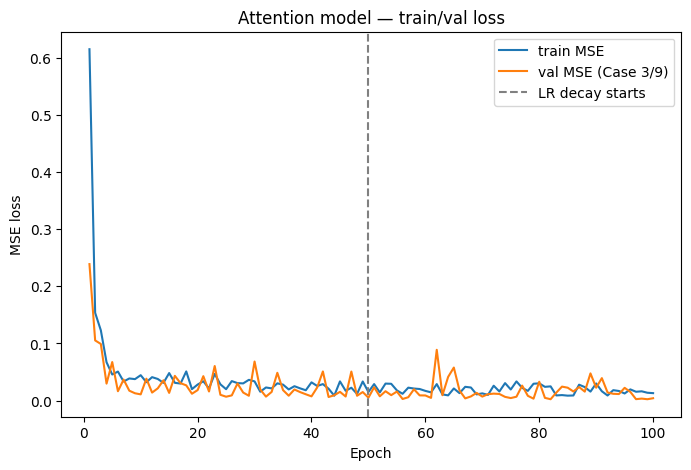

In [ ]:
from unet3d_film_attention import UNet3DFiLMAttention
from diffusion_training import PhasePatchDataset, NoiseScheduler, train
from torch.utils.data import DataLoader

synthetic_case_ids = [c for c in TRAIN_CASES if c not in SYNTHETIC_BLOCKLIST]

train_dataset = PhasePatchDataset(
    data_root=BASE,
    case_ids=TRAIN_CASES,
    patch_size=PATCH_SIZE,
    synthetic_root=SYNTHETIC_ROOT if HAVE_SYNTHETIC else None,
    synthetic_case_ids=synthetic_case_ids if HAVE_SYNTHETIC else None,
)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
print(f"Training samples: {len(train_dataset)}")

val_dataset = PhasePatchDataset(data_root=BASE, case_ids=VAL_CASES, patch_size=PATCH_SIZE)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
print(f"Validation samples: {len(val_dataset)}")

attention_model = UNet3DFiLMAttention(in_channels=3, out_channels=1, base_ch=16)  # fresh random init
scheduler = NoiseScheduler(num_timesteps=1000, device=device)

start = time.time()
result = train(
    attention_model, train_loader, scheduler, device=device,
    epochs=EPOCHS, lr=1e-4,
    checkpoint_dir=ATTENTION_CHECKPOINT_DIR,
    cond_dropout_prob=COND_DROPOUT_PROB,
    use_amp=USE_AMP,
    start_epoch=0,
    lr_decay_start_epoch=LR_DECAY_START_EPOCH,
    val_dataloader=val_loader,
    ema_decay=EMA_DECAY,
    grad_clip_norm=GRAD_CLIP_NORM,
)
elapsed_min = (time.time() - start) / 60
print(f"Training took {elapsed_min:.1f} minutes for {EPOCHS} epochs")

history = result["train_loss"]
val_history = result["val_loss"]

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), history, label="train MSE")
plt.plot(range(1, EPOCHS + 1), val_history, label="val MSE (Case 3/9)")
plt.axvline(LR_DECAY_START_EPOCH, color="gray", linestyle="--", label="LR decay starts")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Attention model — train/val loss")
plt.legend()
plt.show()


# Checkpoint sweep — find the best epoch (raw vs EMA)

Same as your working notebook: checks every 5th epoch 50-100, both raw and EMA, fixed seed
for a fair comparison.


epoch 50 (raw): MSE = 0.1565
epoch 50 (ema): MSE = 0.2155
epoch 55 (raw): MSE = 0.1660
epoch 55 (ema): MSE = 0.2004
epoch 60 (raw): MSE = 0.1976
epoch 60 (ema): MSE = 0.1843
epoch 65 (raw): MSE = 0.1210
epoch 65 (ema): MSE = 0.1720
epoch 70 (raw): MSE = 0.1680
epoch 70 (ema): MSE = 0.1570
epoch 75 (raw): MSE = 0.1987
epoch 75 (ema): MSE = 0.1448
epoch 80 (raw): MSE = 0.0994
epoch 80 (ema): MSE = 0.1347
epoch 85 (raw): MSE = 0.1213
epoch 85 (ema): MSE = 0.1288
epoch 90 (raw): MSE = 0.1236
epoch 90 (ema): MSE = 0.1269
epoch 95 (raw): MSE = 0.1228
epoch 95 (ema): MSE = 0.1243
epoch 100 (raw): MSE = 0.1148
epoch 100 (ema): MSE = 0.1228

Best attention checkpoint (guidance_scale=1.0): epoch 80 (raw), MSE = 0.0994


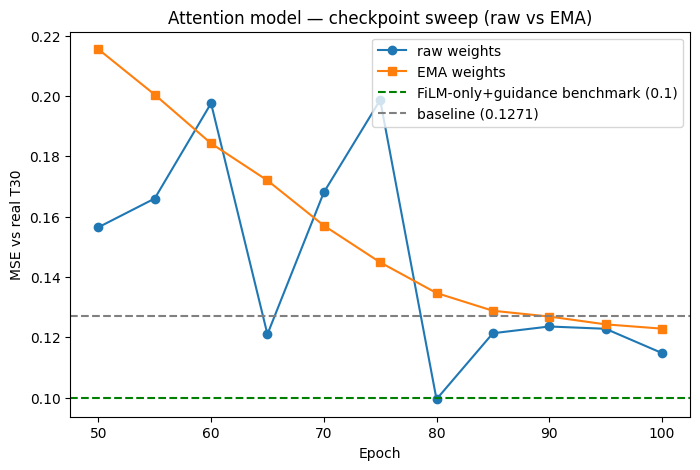

In [ ]:
from ddim_sampling import DDIMSampler
from diffusion_training import INTERMEDIATE_PHASES

EVAL_CROP_SIZE = 48

def center_crop(vol, size):
    d, h, w = vol.shape
    d0, h0, w0 = max(0, (d - size) // 2), max(0, (h - size) // 2), max(0, (w - size) // 2)
    crop = vol[d0:d0 + size, h0:h0 + size, w0:w0 + size]
    pad = [(0, max(0, size - crop.shape[i])) for i in range(3)]
    if any(a or b for a, b in pad):
        crop = np.pad(crop, pad, mode="constant", constant_values=0)
    return crop

case_dir = os.path.join(BASE, "case3")
t00 = center_crop(np.load(os.path.join(case_dir, "T00.npy")).astype(np.float32), EVAL_CROP_SIZE)
t50 = center_crop(np.load(os.path.join(case_dir, "T50.npy")).astype(np.float32), EVAL_CROP_SIZE)
t30_real = center_crop(np.load(os.path.join(case_dir, "T30.npy")).astype(np.float32), EVAL_CROP_SIZE)
t00_t = torch.from_numpy(t00).unsqueeze(0).unsqueeze(0).to(device)
t50_t = torch.from_numpy(t50).unsqueeze(0).unsqueeze(0).to(device)

candidate_epochs = list(range(50, EPOCHS + 1, 5))
mse_by_checkpoint = {}

for ep in candidate_epochs:
    for tag, fname in [("raw", f"epoch_{ep}.pt"), ("ema", f"epoch_{ep}_ema.pt")]:
        ckpt_path = os.path.join(ATTENTION_CHECKPOINT_DIR, fname)
        if not os.path.exists(ckpt_path):
            continue
        m = UNet3DFiLMAttention(in_channels=3, out_channels=1, base_ch=16)
        m.load_state_dict(torch.load(ckpt_path, map_location=device))
        m.to(device).eval()
        s = DDIMSampler(m, scheduler, num_steps=50, device=device)

        torch.manual_seed(42)
        out = s.generate(t00_t, t50_t, phase=0.3, volume_shape=t00.shape, guidance_scale=1.0)
        mse = np.mean((out.squeeze().cpu().numpy() - t30_real) ** 2)
        mse_by_checkpoint[(ep, tag)] = mse
        print(f"epoch {ep} ({tag}): MSE = {mse:.4f}")

best_key = min(mse_by_checkpoint, key=mse_by_checkpoint.get)
best_epoch, best_tag = best_key
print(f"\nBest attention checkpoint (guidance_scale=1.0): epoch {best_epoch} ({best_tag}), "
      f"MSE = {mse_by_checkpoint[best_key]:.4f}")

plt.figure(figsize=(8, 5))
raw_pts = [(ep, mse_by_checkpoint[(ep, "raw")]) for ep in candidate_epochs if (ep, "raw") in mse_by_checkpoint]
ema_pts = [(ep, mse_by_checkpoint[(ep, "ema")]) for ep in candidate_epochs if (ep, "ema") in mse_by_checkpoint]
if raw_pts:
    plt.plot(*zip(*raw_pts), marker='o', label='raw weights')
if ema_pts:
    plt.plot(*zip(*ema_pts), marker='s', label='EMA weights')
plt.axhline(KNOWN_FILM_GUIDED_MEAN_MSE, color='green', linestyle='--',
            label=f'FiLM-only+guidance benchmark ({KNOWN_FILM_GUIDED_MEAN_MSE})')
plt.axhline(KNOWN_BASELINE_MEAN_MSE, color='gray', linestyle='--',
            label=f'baseline ({KNOWN_BASELINE_MEAN_MSE})')
plt.xlabel("Epoch")
plt.ylabel("MSE vs real T30")
plt.title("Attention model — checkpoint sweep (raw vs EMA)")
plt.legend()
plt.show()


# Guidance-scale scan on the best attention checkpoint

Same reasoning as your FiLM-only notebook: this model was also trained with
`cond_dropout_prob=0.15`, so `guidance_scale=1.0` likely leaves real performance on the
table here too. Quick scan before committing to a full sweep.


guidance_scale=1.0: MSE = 0.0945
guidance_scale=1.5: MSE = 0.0477
guidance_scale=2.0: MSE = 0.0345
guidance_scale=2.5: MSE = 0.0350
guidance_scale=3.0: MSE = 0.0380

Best guidance_scale for attention model: 2.0 (MSE=0.0345)


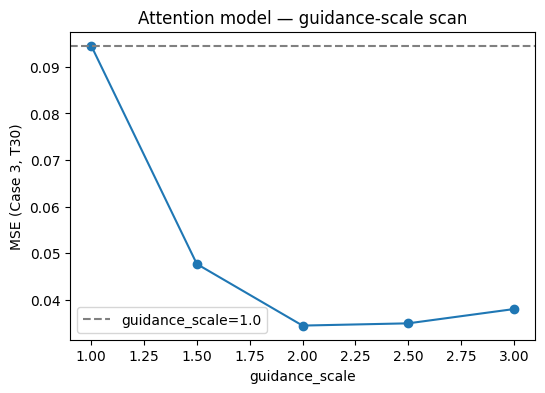

In [ ]:
best_ckpt_path = os.path.join(
    ATTENTION_CHECKPOINT_DIR,
    f"epoch_{best_epoch}.pt" if best_tag == "raw" else f"epoch_{best_epoch}_ema.pt"
)
best_attention_model = UNet3DFiLMAttention(in_channels=3, out_channels=1, base_ch=16)
best_attention_model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
best_attention_model.to(device).eval()
best_attention_sampler = DDIMSampler(best_attention_model, scheduler, num_steps=50, device=device)

guidance_candidates = [1.0, 1.5, 2.0, 2.5, 3.0]
scan_results = {}

for gs in guidance_candidates:
    combined, _, _ = best_attention_sampler.generate_averaged(
        t00_t, t50_t, phase=0.3, volume_shape=t00.shape,
        num_samples=5, guidance_scale=gs, reduction="mean",
    )
    mse = np.mean((combined.squeeze().cpu().numpy() - t30_real) ** 2)
    scan_results[gs] = mse
    print(f"guidance_scale={gs}: MSE = {mse:.4f}")

best_gs = min(scan_results, key=scan_results.get)
print(f"\nBest guidance_scale for attention model: {best_gs} (MSE={scan_results[best_gs]:.4f})")

plt.figure(figsize=(6, 4))
plt.plot(list(scan_results.keys()), list(scan_results.values()), marker='o')
plt.axhline(scan_results[1.0], color='gray', linestyle='--', label='guidance_scale=1.0')
plt.xlabel("guidance_scale")
plt.ylabel("MSE (Case 3, T30)")
plt.title("Attention model — guidance-scale scan")
plt.legend()
plt.show()


# Full held-out verification — attention model vs both reference points

Same protocol as your FiLM-only notebook: 16 phase/case combinations, 5-sample averaging,
at the best guidance scale found above.


In [ ]:
attention_verification_results = {}

for case_id in [3, 9]:
    case_dir_v = os.path.join(BASE, f"case{case_id}")
    if not os.path.exists(case_dir_v):
        print(f"case{case_id} not found -- skipping.")
        continue

    t00_v = center_crop(np.load(os.path.join(case_dir_v, "T00.npy")).astype(np.float32), EVAL_CROP_SIZE)
    t50_v = center_crop(np.load(os.path.join(case_dir_v, "T50.npy")).astype(np.float32), EVAL_CROP_SIZE)
    t00_v_t = torch.from_numpy(t00_v).unsqueeze(0).unsqueeze(0).to(device)
    t50_v_t = torch.from_numpy(t50_v).unsqueeze(0).unsqueeze(0).to(device)

    for phase_name in INTERMEDIATE_PHASES:
        phase_path = os.path.join(case_dir_v, f"{phase_name}.npy")
        if not os.path.exists(phase_path):
            continue
        real_phase = center_crop(np.load(phase_path).astype(np.float32), EVAL_CROP_SIZE)
        phase_val = int(phase_name[1:]) / 100.0

        combined, _, _ = best_attention_sampler.generate_averaged(
            t00_v_t, t50_v_t, phase=phase_val, volume_shape=t00_v.shape,
            num_samples=5, guidance_scale=best_gs, reduction="mean",
        )
        mse = np.mean((combined.squeeze().cpu().numpy() - real_phase) ** 2)
        attention_verification_results[(case_id, phase_name)] = mse
        print(f"[attention, gs={best_gs}] case{case_id} {phase_name}: MSE = {mse:.4f}")

attention_all_mses = list(attention_verification_results.values())
attention_mean_mse = np.mean(attention_all_mses)

print(f"\n--- Final comparison, same 16-combo protocol throughout ---")
print(f"Baseline:              {KNOWN_BASELINE_MEAN_MSE:.4f}")
print(f"FiLM-only + guidance:  {KNOWN_FILM_GUIDED_MEAN_MSE:.4f}  "
      f"({(1 - KNOWN_FILM_GUIDED_MEAN_MSE/KNOWN_BASELINE_MEAN_MSE)*100:+.1f}% vs baseline)")
print(f"Attention + guidance:  {attention_mean_mse:.4f}  "
      f"({(1 - attention_mean_mse/KNOWN_BASELINE_MEAN_MSE)*100:+.1f}% vs baseline, "
      f"{(1 - attention_mean_mse/KNOWN_FILM_GUIDED_MEAN_MSE)*100:+.1f}% vs FiLM-only+guidance)")

if attention_mean_mse < KNOWN_FILM_GUIDED_MEAN_MSE:
    print("\n-> Attention module IMPROVED on the FiLM-only benchmark.")
else:
    print("\n-> Attention module did NOT improve on the FiLM-only benchmark on this evaluation. "
          "That's still a valid, reportable finding -- not every architecture addition helps, "
          "and knowing that (with evidence) is worth more than an untested assumption that it would.")


[attention, gs=2.0] case3 T10: MSE = 0.0340
[attention, gs=2.0] case3 T20: MSE = 0.0329
[attention, gs=2.0] case3 T30: MSE = 0.0345
[attention, gs=2.0] case3 T40: MSE = 0.0350
[attention, gs=2.0] case3 T60: MSE = 0.0373
[attention, gs=2.0] case3 T70: MSE = 0.0343
[attention, gs=2.0] case3 T80: MSE = 0.0366
[attention, gs=2.0] case3 T90: MSE = 0.0426
[attention, gs=2.0] case9 T10: MSE = 0.0359
[attention, gs=2.0] case9 T20: MSE = 0.0377
[attention, gs=2.0] case9 T30: MSE = 0.0400
[attention, gs=2.0] case9 T40: MSE = 0.0447
[attention, gs=2.0] case9 T60: MSE = 0.0436
[attention, gs=2.0] case9 T70: MSE = 0.0405
[attention, gs=2.0] case9 T80: MSE = 0.0376
[attention, gs=2.0] case9 T90: MSE = 0.0374

--- Final comparison, same 16-combo protocol throughout ---
Baseline:              0.1271
FiLM-only + guidance:  0.1000  (+21.3% vs baseline)
Attention + guidance:  0.0378  (+70.3% vs baseline, +62.2% vs FiLM-only+guidance)

-> Attention module IMPROVED on the FiLM-only benchmark.


# Visual comparison — three-way

Real T30 vs FiLM-only+guidance vs Attention+guidance, side by side.


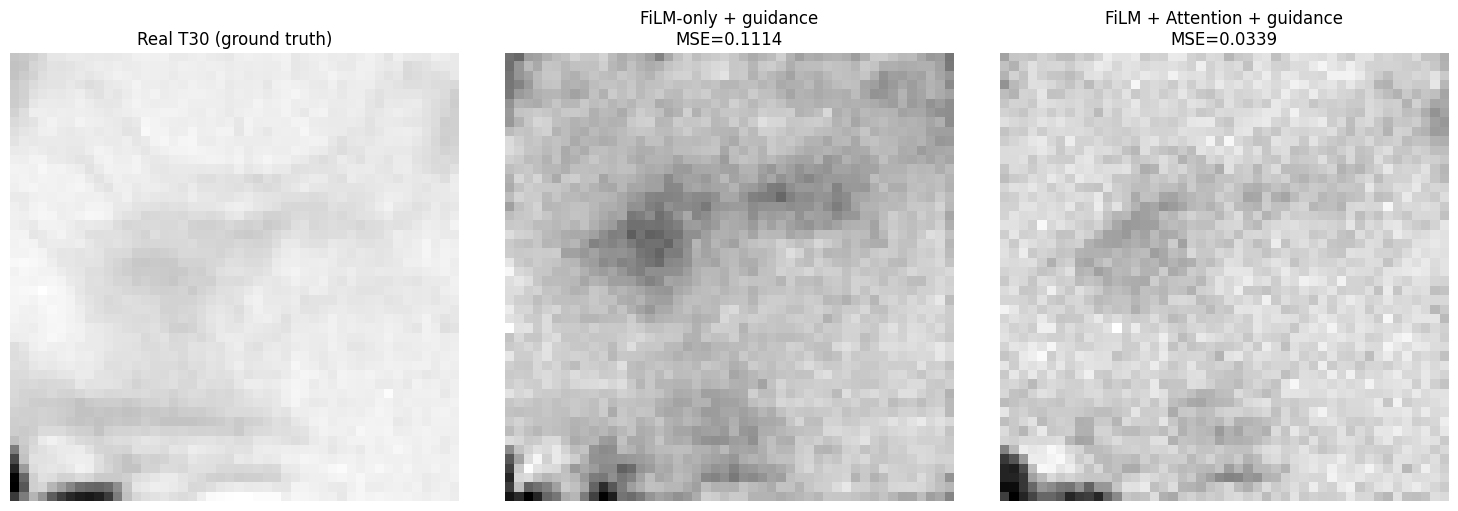

Saved figure to /content/drive/MyDrive/CSE499 Dataset/attention_vs_film_comparison.png


In [ ]:
film_combined = None
if HAVE_BEST_FILM:
    from unet3d_film import UNet3DFiLM
    film_model = UNet3DFiLM(in_channels=3, out_channels=1, base_ch=16)
    film_model.load_state_dict(torch.load(BEST_FILM_CHECKPOINT, map_location=device))
    film_model.to(device).eval()
    film_sampler = DDIMSampler(film_model, scheduler, num_steps=50, device=device)
    film_combined, _, _ = film_sampler.generate_averaged(
        t00_t, t50_t, phase=0.3, volume_shape=t00.shape,
        num_samples=5, guidance_scale=BEST_FILM_GUIDANCE_SCALE, reduction="mean",
    )
    film_np = film_combined.squeeze().cpu().numpy()
else:
    film_np = None
    print("FiLM-only checkpoint not found in this session -- skipping its panel in the figure.")

attention_combined, _, _ = best_attention_sampler.generate_averaged(
    t00_t, t50_t, phase=0.3, volume_shape=t00.shape,
    num_samples=5, guidance_scale=best_gs, reduction="mean",
)
attention_np = attention_combined.squeeze().cpu().numpy()
attention_t30_mse = np.mean((attention_np - t30_real) ** 2)

mid = t00.shape[0] // 2
n_panels = 2 if film_np is None else 3
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5))

axes[0].imshow(t30_real[mid], cmap="gray")
axes[0].set_title("Real T30 (ground truth)")

col = 1
if film_np is not None:
    film_t30_mse = np.mean((film_np - t30_real) ** 2)
    axes[col].imshow(film_np[mid], cmap="gray")
    axes[col].set_title(f"FiLM-only + guidance\nMSE={film_t30_mse:.4f}")
    col += 1

axes[col].imshow(attention_np[mid], cmap="gray")
axes[col].set_title(f"FiLM + Attention + guidance\nMSE={attention_t30_mse:.4f}")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
out_path = os.path.join(PROJECT_ROOT, "attention_vs_film_comparison.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to {out_path}")


In [ ]:
naive_mses = []
for case_id in [3, 9]:
    case_dir_v = os.path.join(BASE, f"case{case_id}")
    t00_v = center_crop(np.load(os.path.join(case_dir_v, "T00.npy")).astype(np.float32), EVAL_CROP_SIZE)
    t50_v = center_crop(np.load(os.path.join(case_dir_v, "T50.npy")).astype(np.float32), EVAL_CROP_SIZE)
    for phase_name in INTERMEDIATE_PHASES:
        phase_path = os.path.join(case_dir_v, f"{phase_name}.npy")
        if not os.path.exists(phase_path):
            continue
        real_phase = center_crop(np.load(phase_path).astype(np.float32), EVAL_CROP_SIZE)
        phase_val = int(phase_name[1:]) / 100.0
        naive_pred = (1 - phase_val) * t00_v + phase_val * t50_v  # plain linear blend, no model at all
        mse = np.mean((naive_pred - real_phase) ** 2)
        naive_mses.append(mse)
        print(f"case{case_id} {phase_name} naive linear blend: MSE = {mse:.4f}")

print(f"\nNaive linear-blend mean MSE: {np.mean(naive_mses):.4f}")
print(f"(compare against: baseline 0.1271, FiLM+guidance 0.1000, attention+guidance 0.0378)")

case3 T10 naive linear blend: MSE = 0.0059
case3 T20 naive linear blend: MSE = 0.0113
case3 T30 naive linear blend: MSE = 0.0113
case3 T40 naive linear blend: MSE = 0.0117
case3 T60 naive linear blend: MSE = 0.0056
case3 T70 naive linear blend: MSE = 0.0045
case3 T80 naive linear blend: MSE = 0.0129
case3 T90 naive linear blend: MSE = 0.0286
case9 T10 naive linear blend: MSE = 0.0071
case9 T20 naive linear blend: MSE = 0.0203
case9 T30 naive linear blend: MSE = 0.0211
case9 T40 naive linear blend: MSE = 0.0185
case9 T60 naive linear blend: MSE = 0.0085
case9 T70 naive linear blend: MSE = 0.0115
case9 T80 naive linear blend: MSE = 0.0204
case9 T90 naive linear blend: MSE = 0.0357

Naive linear-blend mean MSE: 0.0147
(compare against: baseline 0.1271, FiLM+guidance 0.1000, attention+guidance 0.0378)


# Patch Full Generation Further Work

In [ ]:
# --- Step 4: Reload the model + sampler from your saved checkpoint ---
import os
import torch

from unet3d_film_attention import UNet3DFiLMAttention
from ddim_sampling import DDIMSampler
from diffusion_training import NoiseScheduler

scheduler = NoiseScheduler(num_timesteps=1000, device=device)

# Point this at whichever checkpoint you'd already picked as "best" --
# check what's actually in the folder if you don't remember the exact epoch.
print(sorted(os.listdir(ATTENTION_CHECKPOINT_DIR)))

['epoch_1.pt', 'epoch_10.pt', 'epoch_100.pt', 'epoch_100_ema.pt', 'epoch_10_ema.pt', 'epoch_11.pt', 'epoch_11_ema.pt', 'epoch_12.pt', 'epoch_12_ema.pt', 'epoch_13.pt', 'epoch_13_ema.pt', 'epoch_14.pt', 'epoch_14_ema.pt', 'epoch_15.pt', 'epoch_15_ema.pt', 'epoch_16.pt', 'epoch_16_ema.pt', 'epoch_17.pt', 'epoch_17_ema.pt', 'epoch_18.pt', 'epoch_18_ema.pt', 'epoch_19.pt', 'epoch_19_ema.pt', 'epoch_1_ema.pt', 'epoch_2.pt', 'epoch_20.pt', 'epoch_20_ema.pt', 'epoch_21.pt', 'epoch_21_ema.pt', 'epoch_22.pt', 'epoch_22_ema.pt', 'epoch_23.pt', 'epoch_23_ema.pt', 'epoch_24.pt', 'epoch_24_ema.pt', 'epoch_25.pt', 'epoch_25_ema.pt', 'epoch_26.pt', 'epoch_26_ema.pt', 'epoch_27.pt', 'epoch_27_ema.pt', 'epoch_28.pt', 'epoch_28_ema.pt', 'epoch_29.pt', 'epoch_29_ema.pt', 'epoch_2_ema.pt', 'epoch_3.pt', 'epoch_30.pt', 'epoch_30_ema.pt', 'epoch_31.pt', 'epoch_31_ema.pt', 'epoch_32.pt', 'epoch_32_ema.pt', 'epoch_33.pt', 'epoch_33_ema.pt', 'epoch_34.pt', 'epoch_34_ema.pt', 'epoch_35.pt', 'epoch_35_ema.pt', '

In [ ]:
best_epoch = 80
best_tag = "raw"

best_ckpt_path = os.path.join(ATTENTION_CHECKPOINT_DIR, f"epoch_{best_epoch}.pt")
best_attention_model = UNet3DFiLMAttention(in_channels=3, out_channels=1, base_ch=16)
best_attention_model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
best_attention_model.to(device).eval()

best_attention_sampler = DDIMSampler(best_attention_model, scheduler, num_steps=50, device=device)
print(f"Loaded {best_ckpt_path}")

Loaded /content/drive/MyDrive/CSE499 Dataset/checkpoints_attention/epoch_80.pt


In [ ]:
# --- Step 5 ---
best_gs = 2.0

In [ ]:
# --- Step 6: make sure the helper functions exist in this session, then smoke test ---

def pad_to_multiple_of_8(vol):
    pad = [(8 - d % 8) % 8 for d in vol.shape]
    d_pad, h_pad, w_pad = pad
    padded = np.pad(vol, ((0, d_pad), (0, h_pad), (0, w_pad)),
                     mode="constant", constant_values=0)
    return padded, (d_pad, h_pad, w_pad)

def crop_back(vol, pad):
    d_pad, h_pad, w_pad = pad
    d, h, w = vol.shape
    return vol[: d - d_pad if d_pad else d,
               : h - h_pad if h_pad else h,
               : w - w_pad if w_pad else w]

def generate_full_case(case_id, phases, num_samples=1, guidance_scale=1.0, save_dir=None):
    case_dir = os.path.join(BASE, f"case{case_id}")
    t00_raw = np.load(os.path.join(case_dir, "T00.npy")).astype(np.float32)
    t50_raw = np.load(os.path.join(case_dir, "T50.npy")).astype(np.float32)

    t00_pad, pad = pad_to_multiple_of_8(t00_raw)
    t50_pad, _ = pad_to_multiple_of_8(t50_raw)
    print(f"Case {case_id}: real shape {t00_raw.shape} -> padded {t00_pad.shape}")

    t00_t = torch.from_numpy(t00_pad).unsqueeze(0).unsqueeze(0).to(device)
    t50_t = torch.from_numpy(t50_pad).unsqueeze(0).unsqueeze(0).to(device)

    results = {}
    for phase_name in phases:
        phase_val = int(phase_name[1:]) / 100.0
        torch.cuda.empty_cache()
        combined, std_map, _ = best_attention_sampler.generate_averaged(
            t00_t, t50_t, phase=phase_val, volume_shape=t00_pad.shape,
            num_samples=num_samples, guidance_scale=guidance_scale, reduction="mean",
        )
        gen = crop_back(combined.squeeze().cpu().numpy(), pad)
        results[phase_name] = gen
        print(f"  {phase_name}: generated, shape {gen.shape}")
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            np.save(os.path.join(save_dir, f"{phase_name}_full.npy"), gen)
    return results

# Memory smoke test -- ONE phase, ONE sample, no guidance doubling
test_out = generate_full_case(case_id=3, phases=["T30"], num_samples=1, guidance_scale=1.0)

Case 3: real shape (104, 256, 256) -> padded (104, 256, 256)
  T30: generated, shape (104, 256, 256)


/content/ddim_sampling.py:140: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std_map = stacked.std(dim=0)


In [ ]:
from diffusion_training import INTERMEDIATE_PHASES
print(INTERMEDIATE_PHASES)

['T10', 'T20', 'T30', 'T40', 'T60', 'T70', 'T80', 'T90']


In [ ]:
full_case3 = generate_full_case(
    case_id=3,
    phases=INTERMEDIATE_PHASES,   # all 8: T10, T20, T30, T40, T60, T70, T80, T90
    num_samples=5,
    guidance_scale=best_gs,
    save_dir="/content/drive/MyDrive/CSE499 Dataset/full_volume_case3",
)

Case 3: real shape (104, 256, 256) -> padded (104, 256, 256)
  T10: generated, shape (104, 256, 256)
  T20: generated, shape (104, 256, 256)
  T30: generated, shape (104, 256, 256)
  T40: generated, shape (104, 256, 256)
  T60: generated, shape (104, 256, 256)
  T70: generated, shape (104, 256, 256)
  T80: generated, shape (104, 256, 256)
  T90: generated, shape (104, 256, 256)


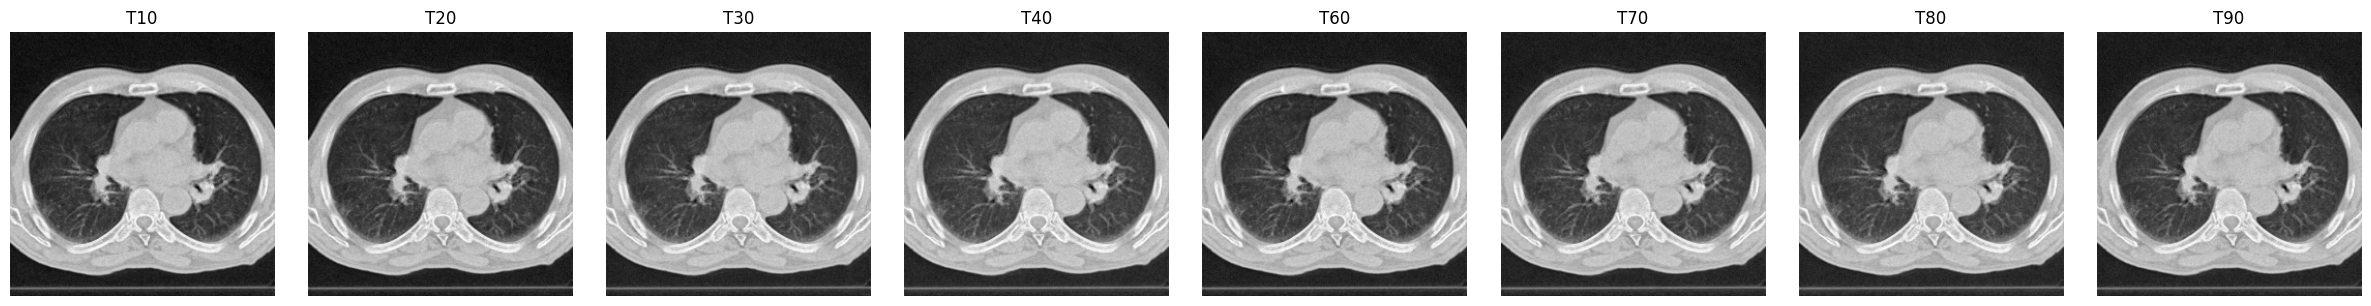

In [ ]:
import matplotlib.pyplot as plt

save_dir = "/content/drive/MyDrive/CSE499 Dataset/full_volume_case3"
phases_to_check = ["T10", "T20", "T30", "T40", "T60", "T70", "T80", "T90"]

fig, axes = plt.subplots(1, len(phases_to_check), figsize=(3 * len(phases_to_check), 3))
for ax, phase_name in zip(axes, phases_to_check):
    vol = np.load(os.path.join(save_dir, f"{phase_name}_full.npy"))
    mid_slice = vol.shape[0] // 2
    ax.imshow(vol[mid_slice], cmap="gray")
    ax.set_title(phase_name)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
case_dir = os.path.join(BASE, "case3")
t00_real = np.load(os.path.join(case_dir, "T00.npy")).astype(np.float32)
t50_real = np.load(os.path.join(case_dir, "T50.npy")).astype(np.float32)

full_4d_scan = {"T00": t00_real, "T50": t50_real}
for phase_name in phases_to_check:
    full_4d_scan[phase_name] = np.load(os.path.join(save_dir, f"{phase_name}_full.npy"))

save_path = os.path.join(save_dir, "full_4d_scan.npz")
np.savez(save_path, **full_4d_scan)
print(f"Saved complete 10-phase 4D scan to {save_path}")

Saved complete 10-phase 4D scan to /content/drive/MyDrive/CSE499 Dataset/full_volume_case3/full_4d_scan.npz


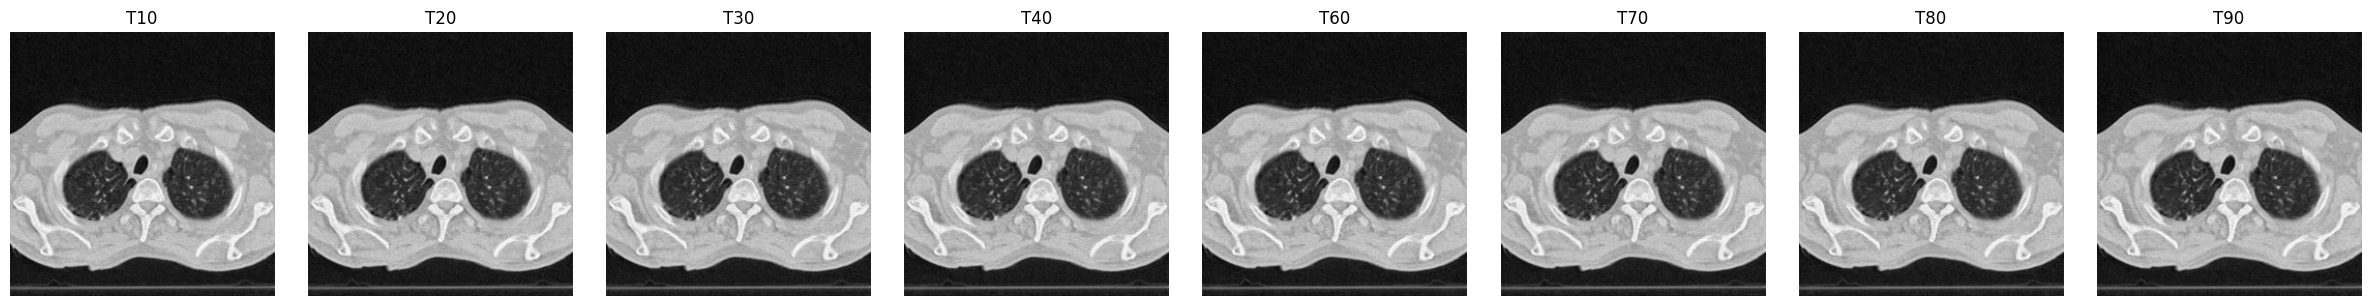

Mean absolute difference T10 vs T90: 0.03640734
Max absolute difference T10 vs T90: 0.54977787


In [ ]:
# Check a lower slice (closer to diaphragm) where motion should be most visible
low_slice = int(t00_real.shape[0] * 0.15)  # ~15% from one end -- try both ends if unsure of orientation

fig, axes = plt.subplots(1, 8, figsize=(24, 3))
for ax, phase_name in zip(axes, phases_to_check):
    vol = np.load(os.path.join(save_dir, f"{phase_name}_full.npy"))
    ax.imshow(vol[low_slice], cmap="gray")
    ax.set_title(phase_name)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Quantify: is there ANY real difference between the earliest and latest generated phase?
t10 = np.load(os.path.join(save_dir, "T10_full.npy"))
t90 = np.load(os.path.join(save_dir, "T90_full.npy"))
print("Mean absolute difference T10 vs T90:", np.mean(np.abs(t10 - t90)))
print("Max absolute difference T10 vs T90:", np.max(np.abs(t10 - t90)))

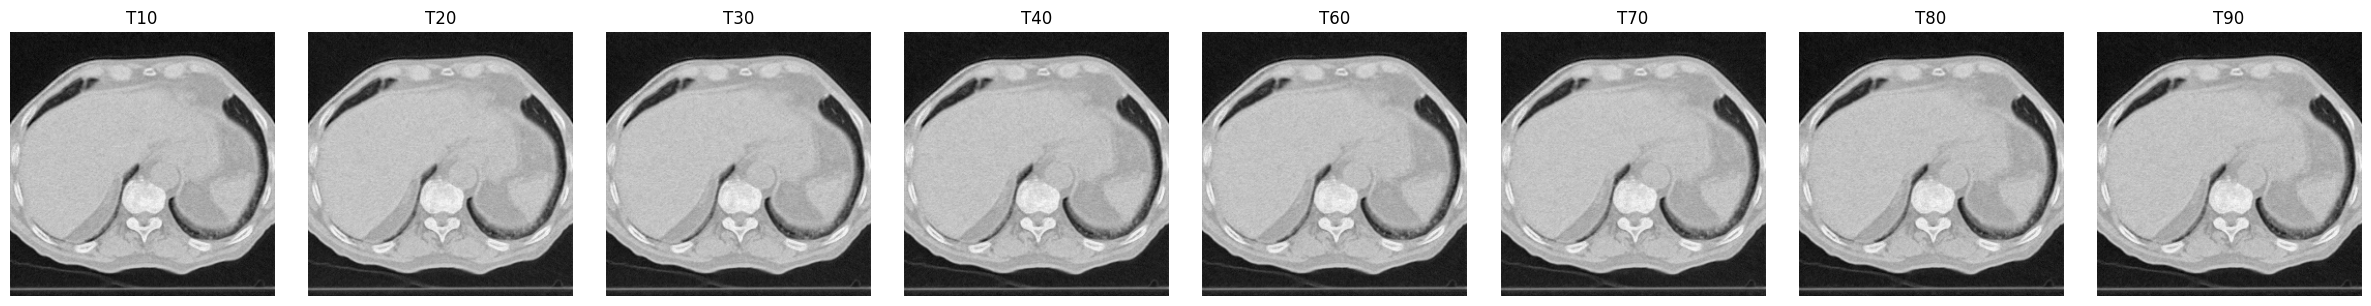

Slice with largest difference: index 98 out of 104


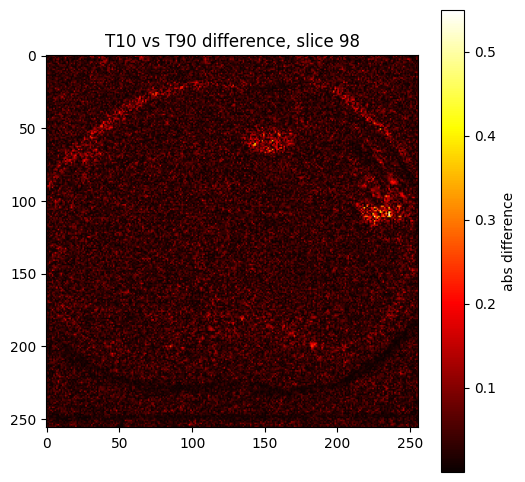

In [ ]:
# Try the OTHER end -- likely closer to the diaphragm
low_slice2 = int(t00_real.shape[0] * 0.85)

fig, axes = plt.subplots(1, 8, figsize=(24, 3))
for ax, phase_name in zip(axes, phases_to_check):
    vol = np.load(os.path.join(save_dir, f"{phase_name}_full.npy"))
    ax.imshow(vol[low_slice2], cmap="gray")
    ax.set_title(phase_name)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Visualize WHERE the T10 vs T90 difference actually is, as a heatmap
diff_map = np.abs(t90 - t10)  # (D, H, W)
slice_with_max_diff = np.unravel_index(np.argmax(diff_map), diff_map.shape)[0]
print(f"Slice with largest difference: index {slice_with_max_diff} out of {diff_map.shape[0]}")

plt.figure(figsize=(6, 6))
plt.imshow(diff_map[slice_with_max_diff], cmap="hot")
plt.colorbar(label="abs difference")
plt.title(f"T10 vs T90 difference, slice {slice_with_max_diff}")
plt.show()

REAL scan  -- mean diff T10 vs T90: 0.033920072  max: 1.3671428
GENERATED  -- mean diff T10 vs T90: 0.03640734  max: 0.54977787


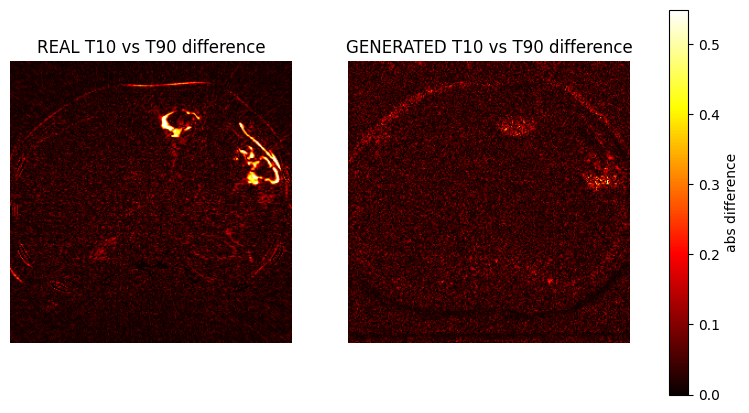

In [ ]:
case_dir = os.path.join(BASE, "case3")
t10_real = np.load(os.path.join(case_dir, "T10.npy")).astype(np.float32)
t90_real = np.load(os.path.join(case_dir, "T90.npy")).astype(np.float32)

real_diff = np.abs(t90_real - t10_real)
print("REAL scan  -- mean diff T10 vs T90:", np.mean(real_diff), " max:", np.max(real_diff))
print("GENERATED  -- mean diff T10 vs T90:", np.mean(diff_map), " max:", np.max(diff_map))

# Same slice, side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(real_diff[slice_with_max_diff], cmap="hot", vmax=diff_map.max())
axes[0].set_title("REAL T10 vs T90 difference")
axes[1].imshow(diff_map[slice_with_max_diff], cmap="hot", vmax=diff_map.max())
axes[1].set_title("GENERATED T10 vs T90 difference")
for ax in axes:
    ax.axis("off")
plt.colorbar(axes[0].images[0], ax=axes, label="abs difference")
plt.show()